In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import asyncpg
import asyncio

async def get_conn():
    return await asyncpg.connect(
        host='localhost',
        port=5432,
        database='ipl_analytics',
        user='postgres',
        password='postgres'
    )

# Test connection
async def test():
    conn = await get_conn()
    print("Connected!")
    await conn.close()

await test()

Connected!


In [13]:
async def powerplay_runs():
    conn = await get_conn()
    
    query = """
        SELECT 
            m.season,
            t.team_name,
            COUNT(DISTINCT d.match_id) as matches,
            SUM(d.runs_total) as total_runs,
            COUNT(*) as total_balls,
            ROUND(SUM(d.runs_total) * 6.0 / COUNT(*), 2) as run_rate,
            ROUND(SUM(d.runs_total)::numeric / COUNT(DISTINCT d.match_id), 2) as avg_pp_score
        FROM deliveries d
        JOIN matches m ON d.match_id = m.match_id
        JOIN teams t ON d.batting_team_id = t.team_id
        WHERE d.over_num BETWEEN 0 AND 5
        AND m.season IN ('2021', '2022', '2023', '2024', '2025', '2026')
        AND d.is_super_over = FALSE
        GROUP BY t.team_name, m.season
        ORDER BY run_rate DESC
    """
    
    rows = await conn.fetch(query)
    await conn.close()
    return pd.DataFrame(rows, columns=['season','team', 'matches', 'total_runs', 'total_balls', 'run_rate', 'avg_pp_score'])

df_pp = await powerplay_runs()
df_pp

,season,team,matches,total_runs,total_balls,run_rate,avg_pp_score
0,2026,Punjab Kings,6,456,230,11.90,76.00
1,2026,Rajasthan Royals,8,552,305,10.86,69.00
2,2024,Sunrisers Hyderabad,16,1073,605,10.64,67.06
3,2024,Kolkata Knight Riders,14,930,531,10.51,66.43
4,2026,Sunrisers Hyderabad,8,542,310,10.49,67.75
5,2025,Rajasthan Royals,14,914,525,10.45,65.29
6,2026,Royal Challengers Bengaluru,7,436,258,10.14,62.29
7,2024,Delhi Capitals,14,897,531,10.14,64.07
8,2025,Punjab Kings,18,1075,668,9.66,59.72
9,2024,Royal Challengers Bengaluru,15,876,552,9.52,58.40


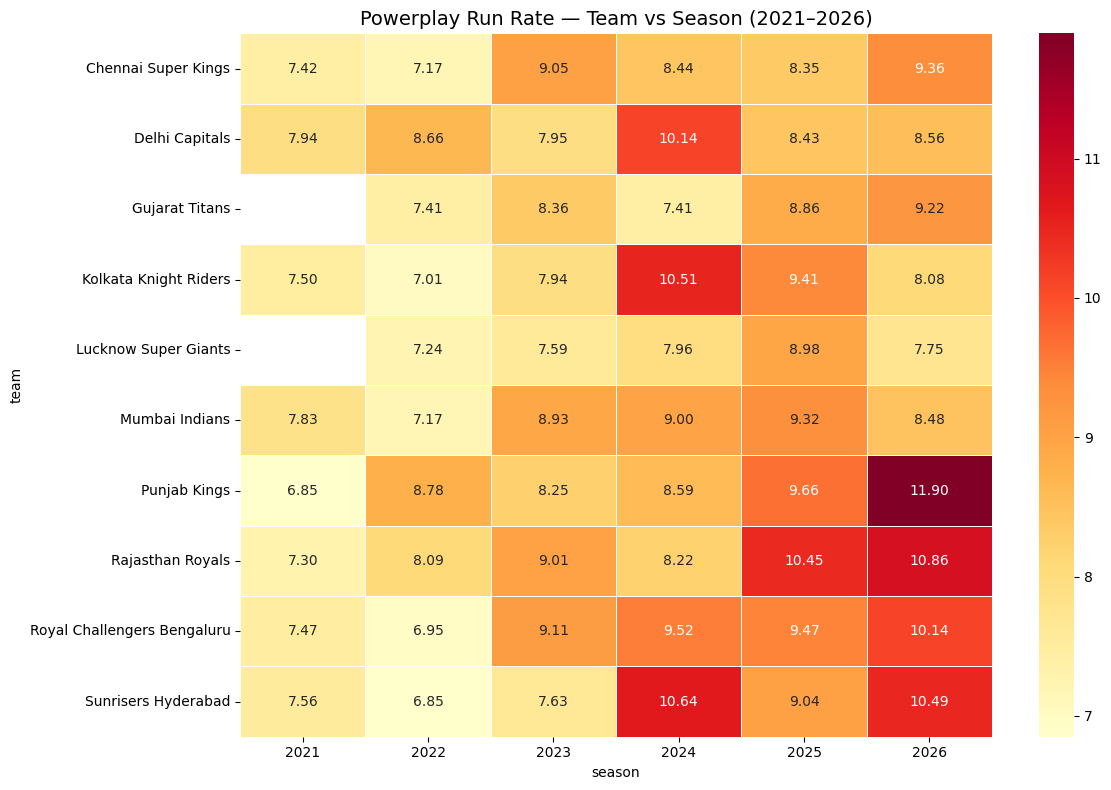

In [16]:
pivot = df_pp.pivot_table(index='team', columns='season', values='run_rate')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot.astype(float), annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Powerplay Run Rate — Team vs Season (2021–2026)', fontsize=14)
plt.tight_layout()
plt.show()

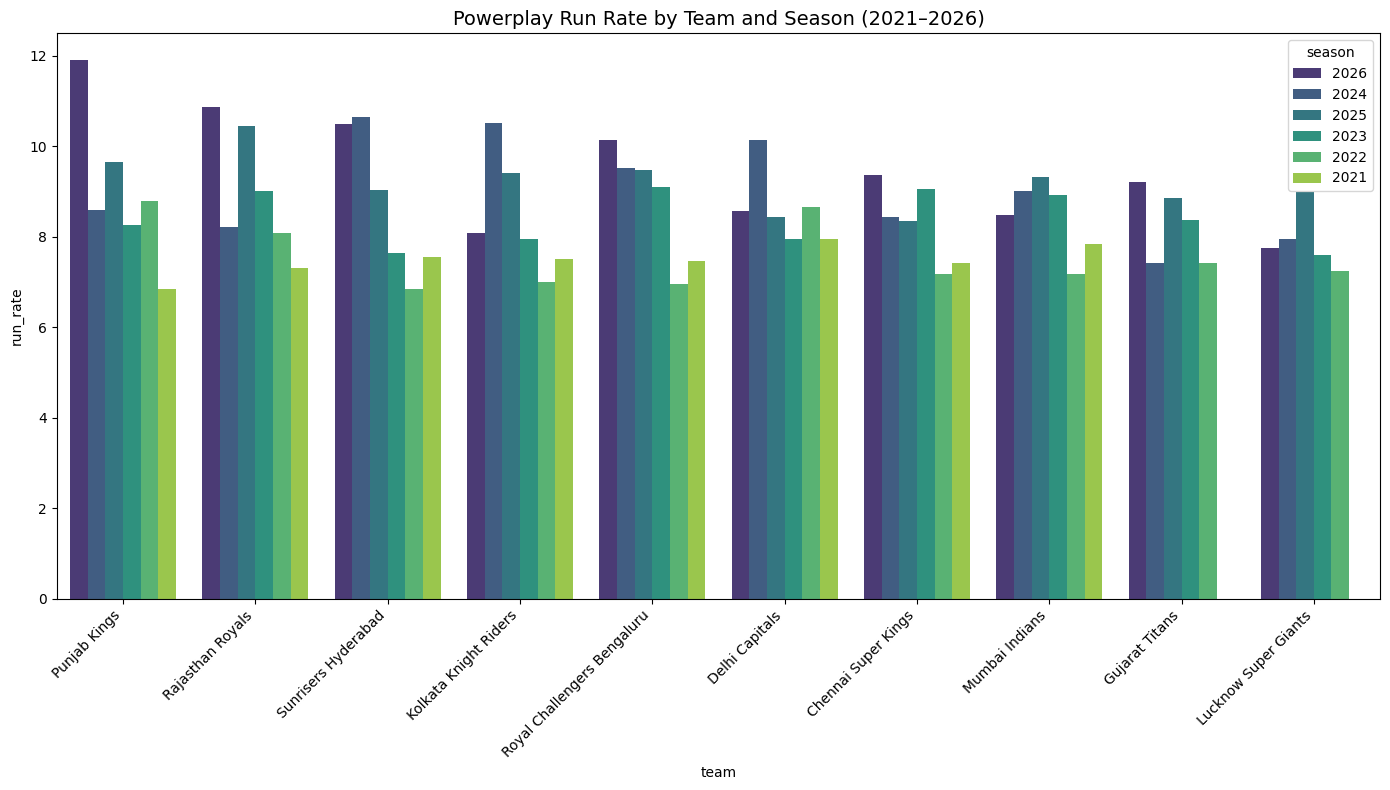

In [15]:
plt.figure(figsize=(14, 8))
sns.barplot(data=df_pp, x='team', y='run_rate', hue='season', palette='viridis')
plt.title('Powerplay Run Rate by Team and Season (2021–2026)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()